In [29]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# CONFIG
# ==============================
DATASET_PATH = r"C:\Users\Admin\Downloads\UTKFace"
IMG_SIZE = 96
LIMIT = 8000

# ==============================
# LOAD DATA
# ==============================
images = []
genders = []

files = os.listdir(DATASET_PATH)[:LIMIT]

for file in files:
    try:
        age, gender = file.split('_')[:2]
        img_path = os.path.join(DATASET_PATH, file)

        img = Image.open(img_path).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))

        img = np.array(img, dtype=np.float32) / 255.0

        images.append(img)
        genders.append(int(gender))
    except:
        continue

X = np.array(images)
y = np.array(genders)

print("Unique labels:", np.unique(y))
print("Sample labels:", y[:20])

print("Data shape:", X.shape)

# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# MODEL
# ==============================
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==============================
# TRAIN
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

# ==============================
# EVALUATION
# ==============================
pred = (model.predict(X_test) > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

Unique labels: [0 1]
Sample labels: [0 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0]
Data shape: (8000, 96, 96, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 94, 94, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 94, 94, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 45, 45, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 20, 20, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 923,073 (3.52 MB)

 Trainable params: 922,113 (3.52 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 386ms/step - accuracy: 0.6475 - loss: 0.7108 - val_accuracy: 0.4331 - val_loss: 1.5304
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 329ms/step - accuracy: 0.7691 - loss: 0.4791 - val_accuracy: 0.7475 - val_loss: 0.4885
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.7969 - loss: 0.4157 - val_accuracy: 0.7625 - val_loss: 0.4908
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 65s 326ms/step - accuracy: 0.8261 - loss: 0.3712 - val_accuracy: 0.8338 - val_loss: 0.3327
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 65s 325ms/step - accuracy: 0.8422 - loss: 0.3314 - val_accuracy: 0.8112 - val_loss: 0.3823
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 330ms/step - accuracy: 0.8603 - loss: 0.3105 - val_accuracy: 0.8306 - val_loss: 0.3317
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 331ms/step - accuracy: 0.8731 - loss: 0.2888 - val_accuracy: 0.8194 - val_loss: 0.3642
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 332ms/step - accuracy: 0.8777 - loss: 0

In [30]:
# pick 5 samples
for i in range(5):
    sample = np.expand_dims(X_test[i], axis=0)
    pred = model.predict(sample)[0][0]
    print("True:", y_test[i], "Pred:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
True: 1 Pred: 0.41970304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
True: 1 Pred: 0.47556767
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
True: 0 Pred: 0.43477926
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
True: 0 Pred: 0.0038159166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
True: 0 Pred: 0.00072893774


In [59]:
def predict_image(path):
    original = Image.open(path).convert("RGB")

    img = original.resize((96, 96))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred < 0.35:
        gender = "Male"
    elif pred > 0.55:
        gender = "Female"
    else:
        gender = "Uncertain"

    confidence = pred if pred > 0.5 else 1 - pred

    plt.imshow(original)
    plt.axis("off")
    plt.title(f"{gender} ({confidence:.2f})")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


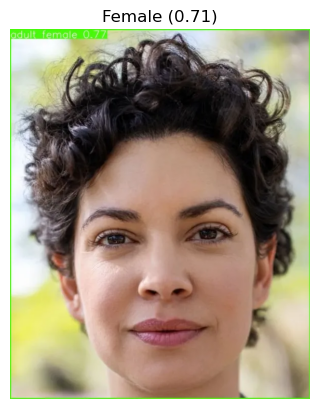

In [60]:
predict_image(r"C:\Users\Admin\Downloads\face1.webp")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


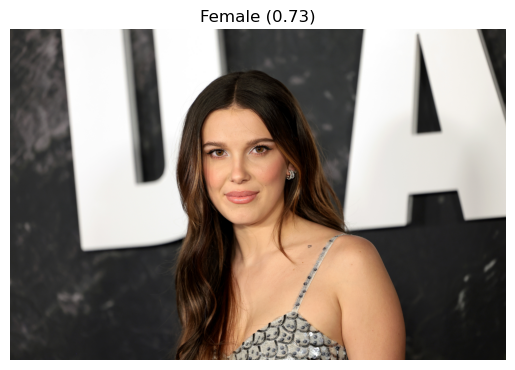

In [61]:
predict_image(r"C:\Users\Admin\Downloads\milley.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


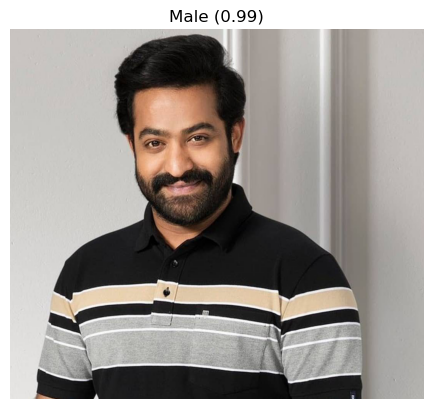

In [62]:
predict_image(r"C:\Users\Admin\Downloads\ntr.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


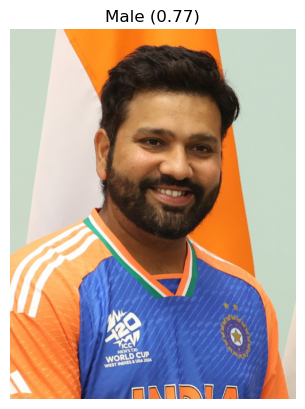

In [63]:
predict_image(r"C:\Users\Admin\Downloads\hitman.jpg")

In [64]:
model.save("gender_model.h5")